# Лабораторна робота №1

Автори оригінальної лабараторної невідомі. Автор видозміненої - Іван Зарицький

# Перетворення Фур'є

На парах математичного аналізу ви познайомилися з **рядами Фур'є** - інструментом, який дозволяє довільну періодичну функцію оцінити як рівномірно збіжний ряд з тригонометричних функцій. У цій роботі ми познайомимось з дотичним і дуже потужним інструментом - **дискретним перетвореннями Фур'є**.

Говорячи науково, перевторення Фур'є - це переклад неперервного сигналу (хвилі) з формату "час-амплітуда" (**time domain**), де для кожної одиниці часу ми записуємо "гучність" хвилі, у формат "частота-амплітуда" (**frequency domain**), де ми маємо різні частоти, для кожної з якої знаємо її "гучність" у вихідному сигналі.

### **Матеріали:**</br>
Потрібно для виконання лаби:
- 3blue1brown (Fast Fourier Transform) - https://www.youtube.com/watch?v=spUNpyF58BY
- https://medium.com/towards-data-science/understanding-audio-data-fourier-transform-fft-spectrogram-and-speech-recognition-a4072d228520

Погратися:
- https://prajwalsouza.github.io/Experiments/Fourier-Transform-Visualization.html
- https://www.jezzamon.com/fourier/index.html

Additional:
- 3blue1brown (ряди фур’є) - https://www.youtube.com/watch?v=r6sGWTCMz2k&t=8s
- How shazam works? - https://medium.com/@anaharris/how-does-shazam-work-d38f74e41359
- Тут можна створити хвилю і послухати звук: https://www.mathsisfun.com/physics/audio-spectrum-beats.html
- Deep learning for audio intro: https://www.youtube.com/watch?v=Z7YM-HAz-IY&list=PLhA3b2k8R3t2Ng1WW_7MiXeh1pfQJQi_P

For nerds:
- https://www.youtube.com/watch?v=E8HeD-MUrjY

In [1]:
import librosa
from librosa import display
from IPython.display import Audio, display
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack as fftp
from scipy.fft import fft, fftfreq
import seaborn as sns
sns.set()

### Трохи прикладів

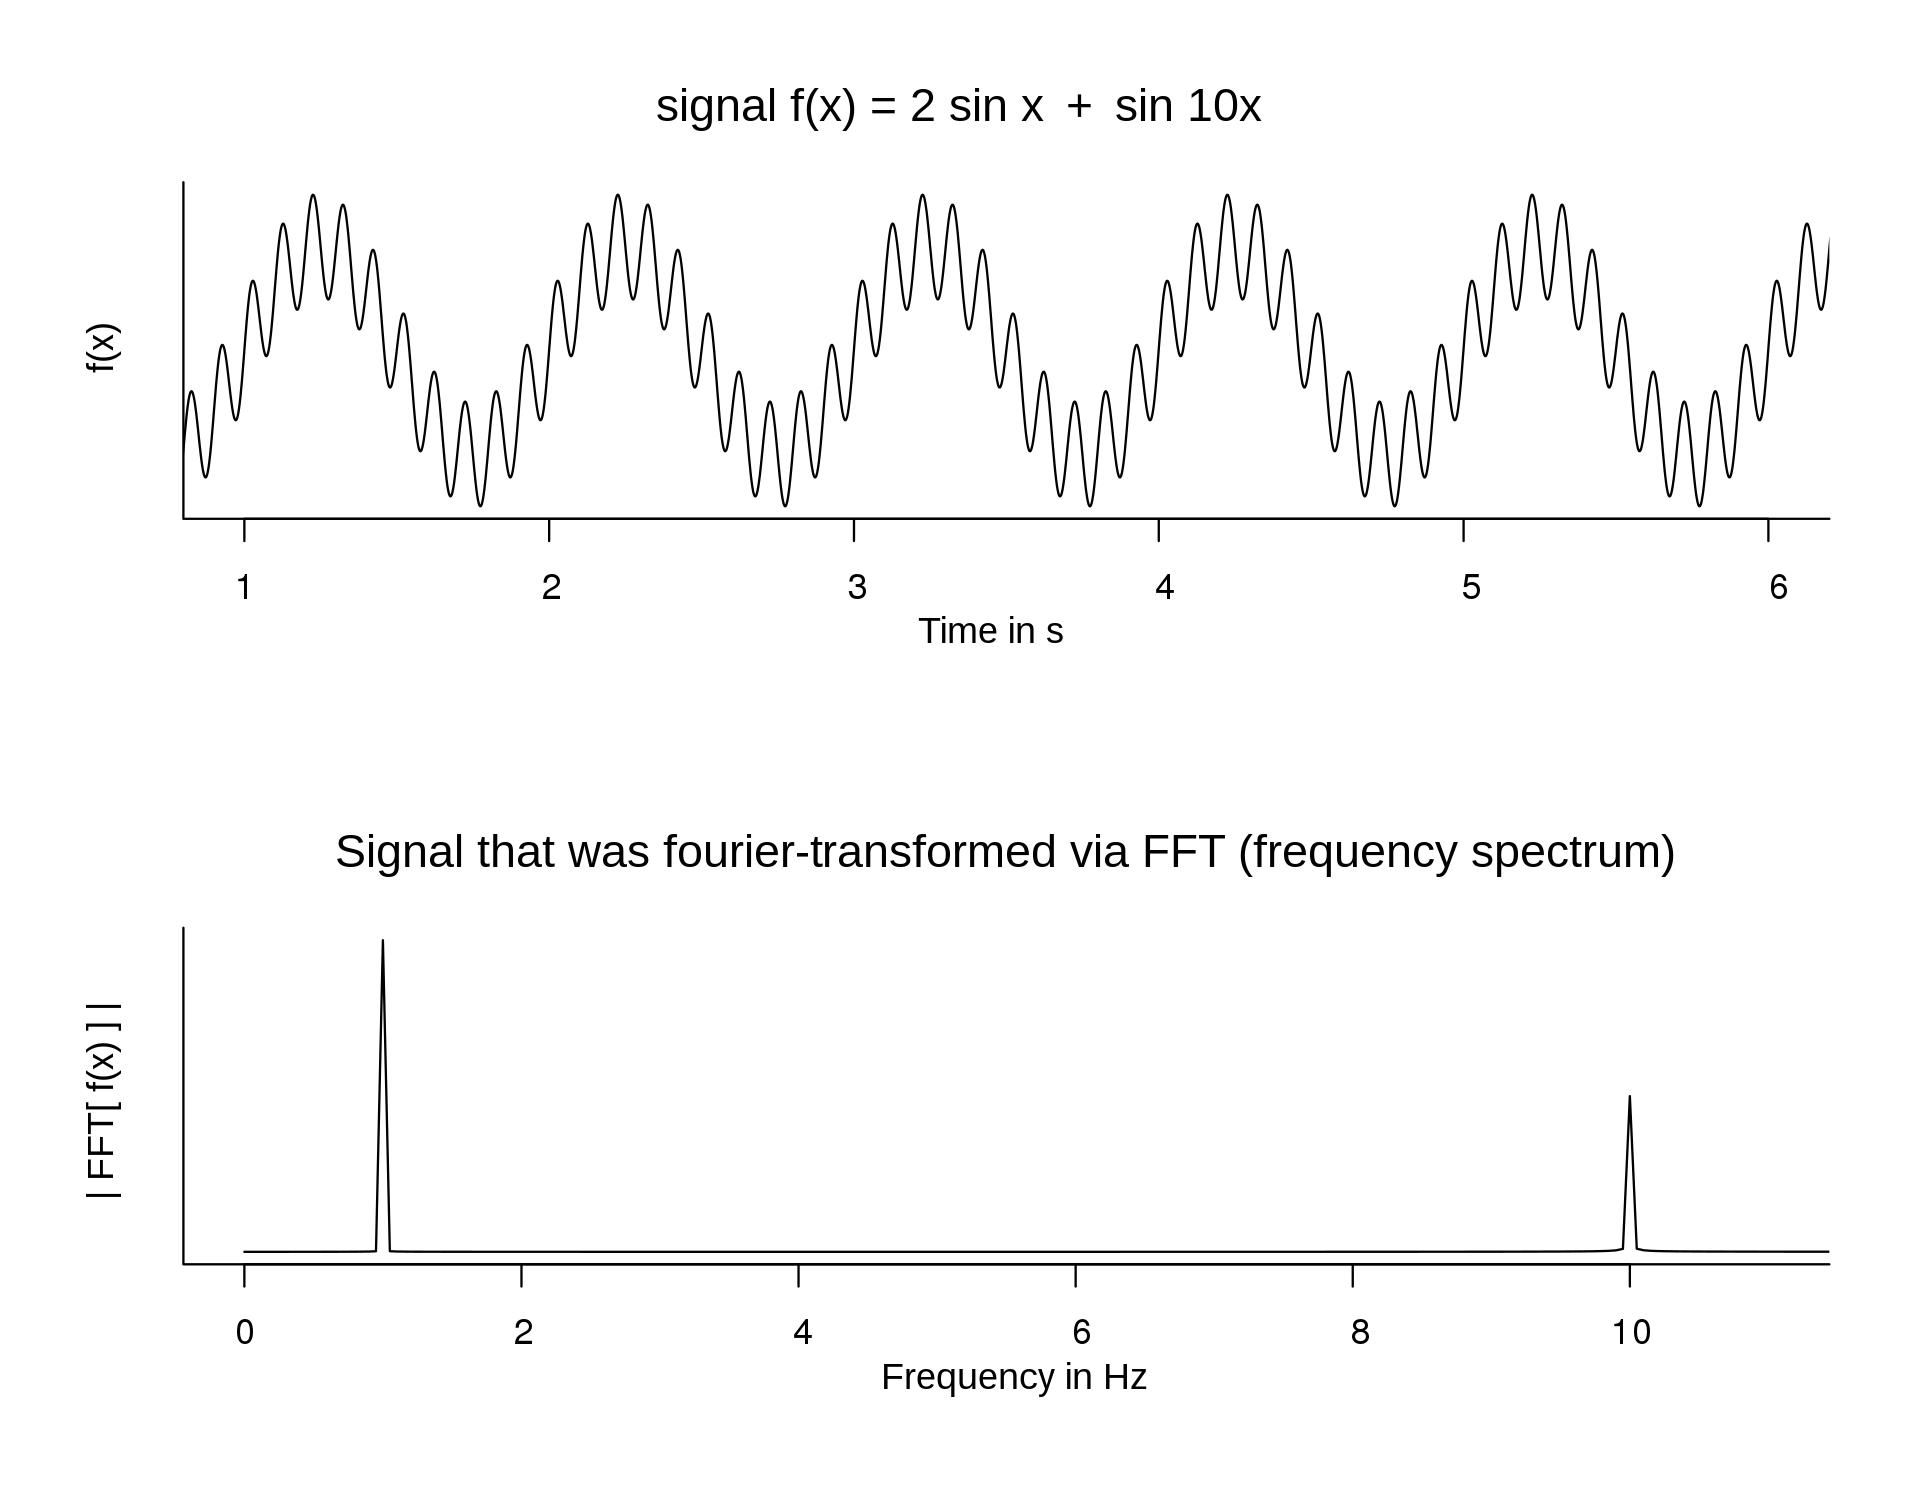

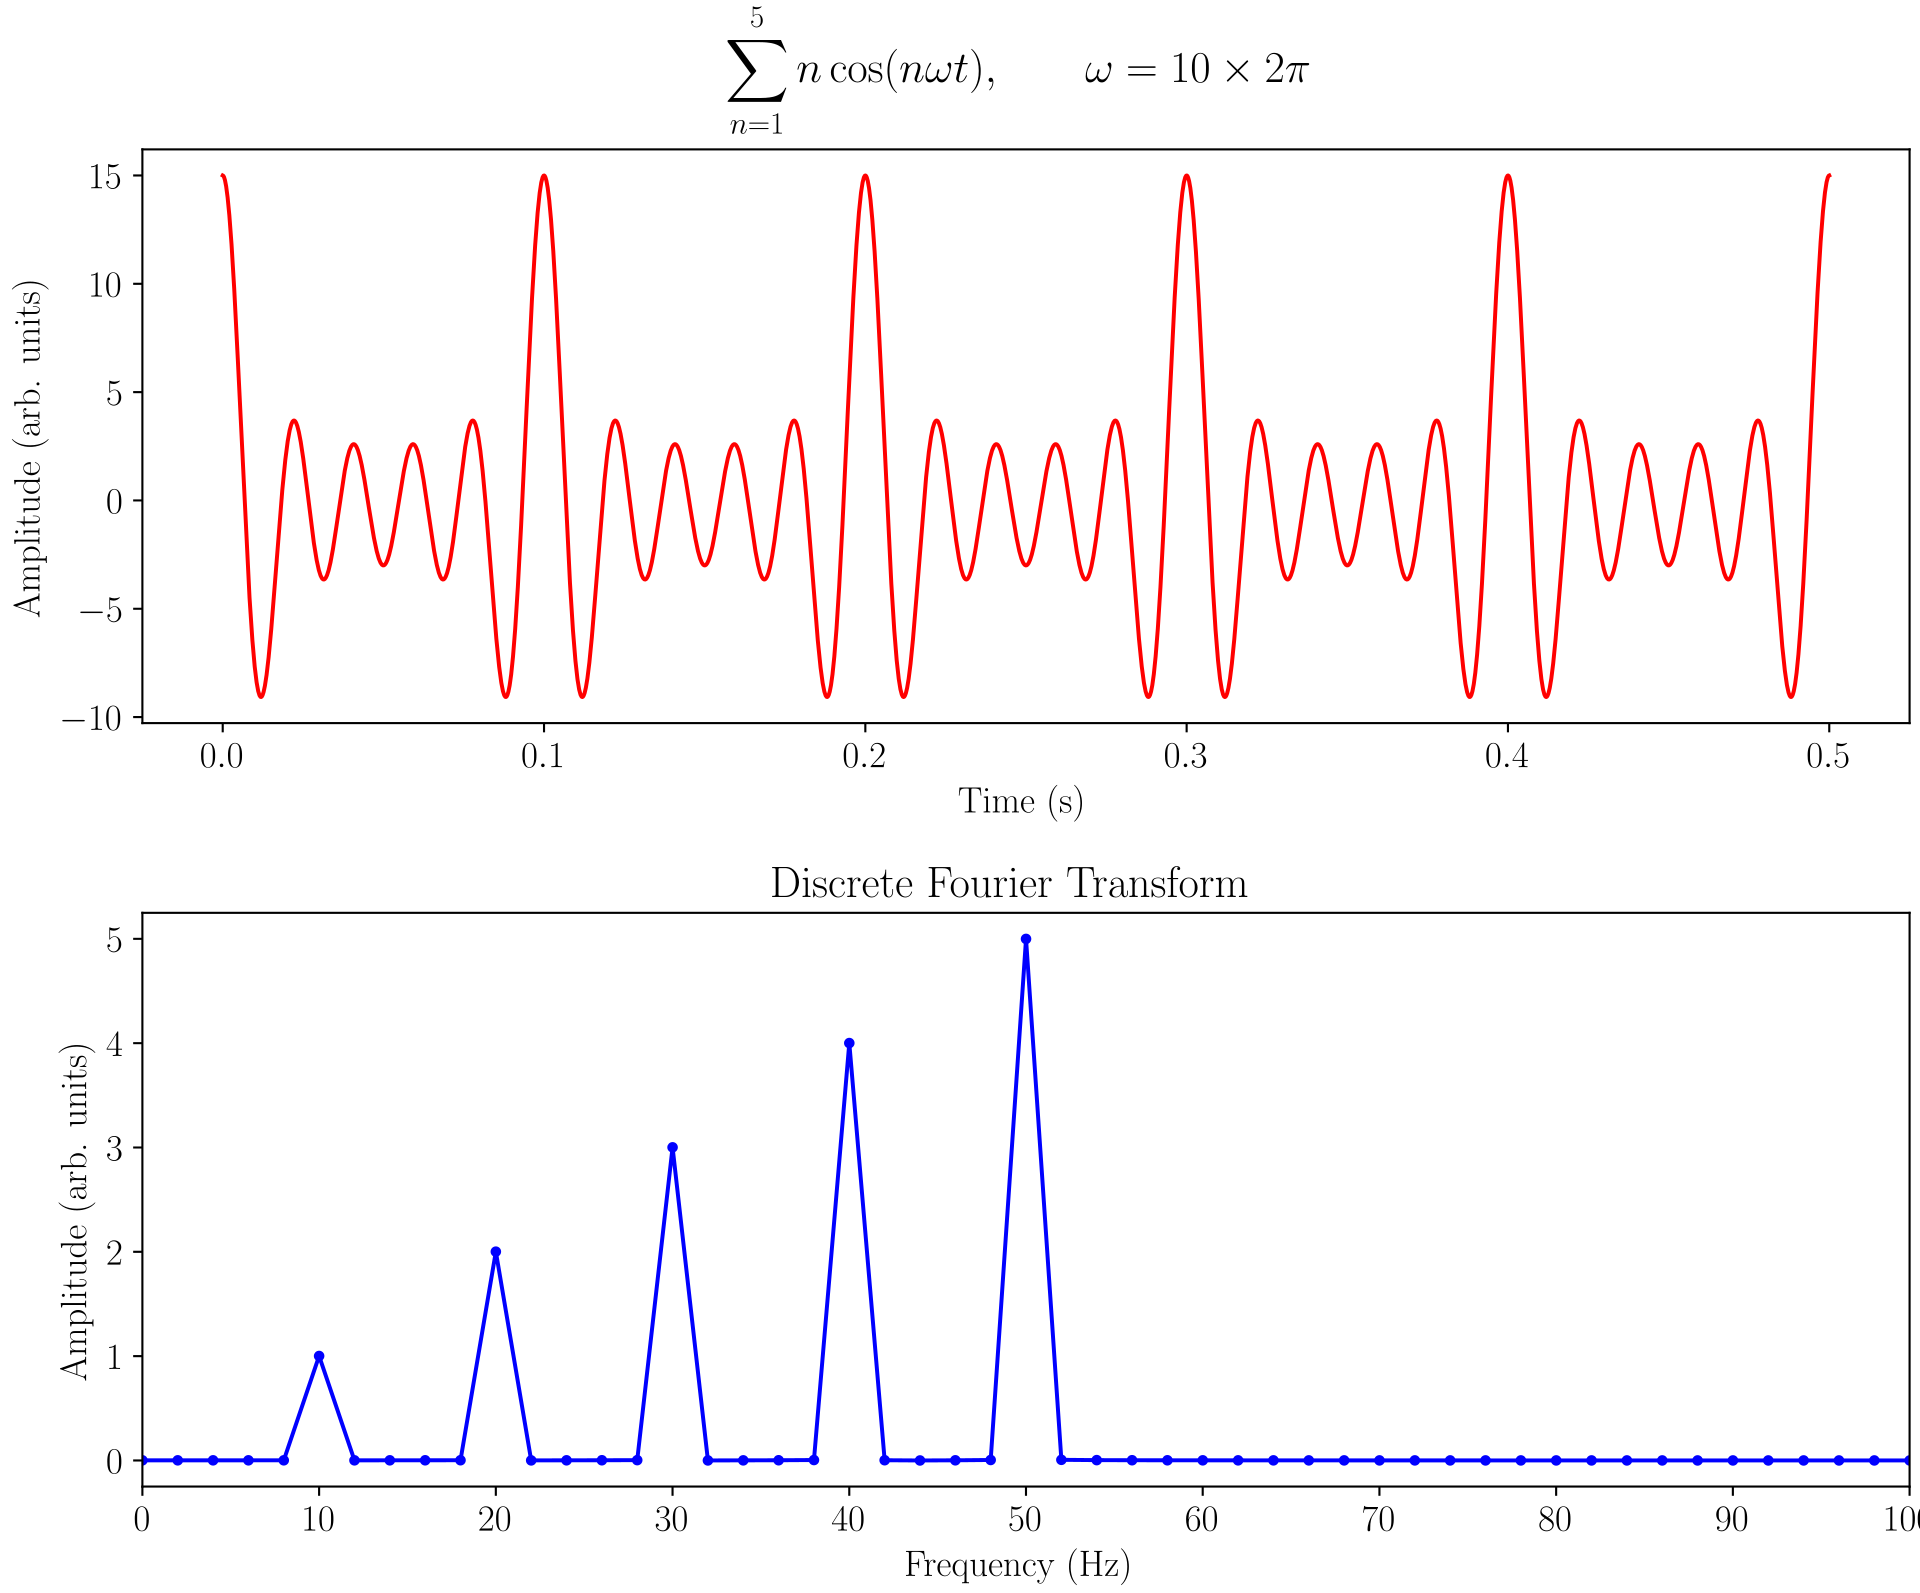

FFT (*Fast Fourier Transform*) - алгоритм для отримання перетворення Фур'є. Головна його перевага - він **скорочує асимптотичну складність** аналізу з $O(N^2)$ до $O(N\log N)$. Наприклад, на двох масивах розміром у 100к елементів, функція np.convolve(arr1, arr2), яка використовується для пошуку накладання сигналів, працює всередньому близько 5 секунд, а scipy.signal.fftconvolve(arr1, arr2) - **у тисячу разів швидше** - ~5 мікросекунд. Ще одна демонстрація того, наскільки впливова асимптотична складність

**Приклад як працює дискретне перетворення Фур'є:**

Тут ми зобразили суму двох хвиль-cинусоїдів.

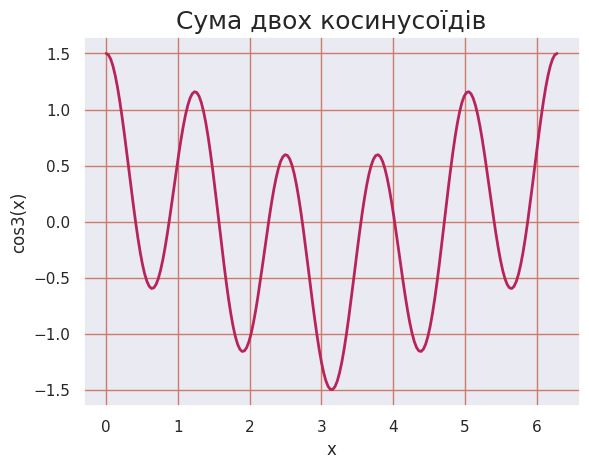

In [2]:
T_cos3 = 2 * np.pi
N_cos3 = 200
x = np.linspace(0, T_cos3, N_cos3)
dt_cos3 = np.diff(x)[0]
cos1 = 0.5 * np.cos(x)
cos2 = np.cos(5*x)
cos3 = cos1 + cos2
plt.plot(x, cos3, color='#b7245c',
     linewidth=2)
plt.title('Сума двох косинусоїдів', fontsize=18)
plt.xlabel("x")
plt.ylabel("сos3(x)")
plt.grid(color='#ce796b')
plt.show()

Як можна побачити хвиля достатньо хаотична та не несе жодної важливої інформації.

Але ми можемо використати FFT, щоб зробити декомпозицію нашої хвилі та отримати важливу інформацію для нас, особливо про її "піки".

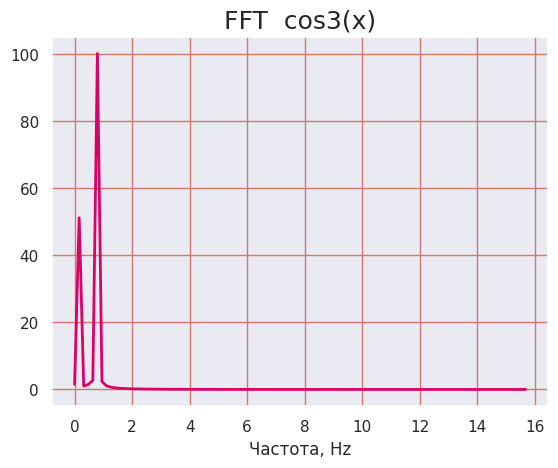

In [3]:
cos3_freq = fftfreq(N_cos3, dt_cos3)
cos3_fft = fft(cos3)
plt.plot(cos3_freq[:N_cos3//2], np.abs(cos3_fft[:N_cos3//2]), color='#d90368',linewidth=2)
plt.title("FFT  cos3(x)", fontsize=18)
plt.xlabel("Частота, Hz")
plt.grid(color='#ce796b')
plt.show()

Matplotlib дає зручну можливість наближати графіки - тож можна краще розгледіти "піки" - найгучніші частоти оригінального запису

### Робота з аудіофайлами

В архіві прикріпленому до завдання знаходиться 3 аудіофайли, першим ділом потрібно загрузити один з цих файлів (або взяти свій) і вивести кількість семплів та sampling rate. Для цього скористайтеся python бібліотекою - librosa.

In [13]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

audio_file = 'sound/sound3.wav'

samples, sample_rate = librosa.load(audio_file, sr=None)

print(f"Кількість семплів: {len(samples)}")
print(f"Sampling rate (частота дискретизації): {sample_rate} Гц")

Кількість семплів: 64512
Sampling rate (частота дискретизації): 44100 Гц


Тепер знайдіть тривалість аудіофайлу в секундах поділивши кількість семплів на sampling rate

In [14]:
duration = len(samples) / sample_rate
print(f"Тривалість аудіофайлу: {duration:.2f} секунд")

Тривалість аудіофайлу: 1.46 секунд


Аудіофайл можна слухати в notebook за допомогою функції Audio імпортованої вище

In [15]:
from IPython.display import Audio

Audio(data=samples, rate=sample_rate)

Ми отримали амплітуди (samples) та частоту дискретизації(sample rate) з librosa. Ми можемо легко побудувати графік залежності цих амплітуд від часу. Приклад: 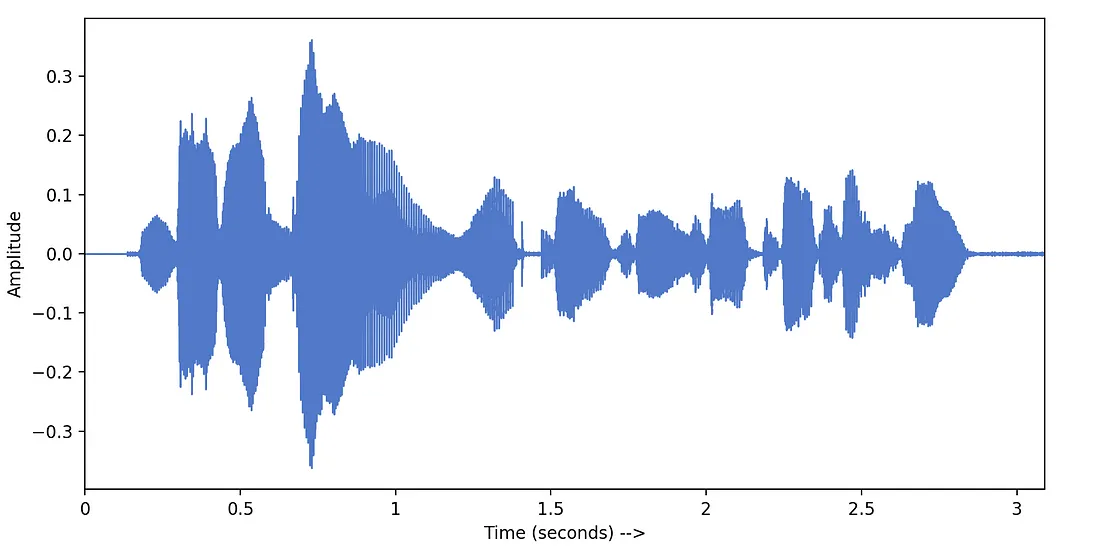

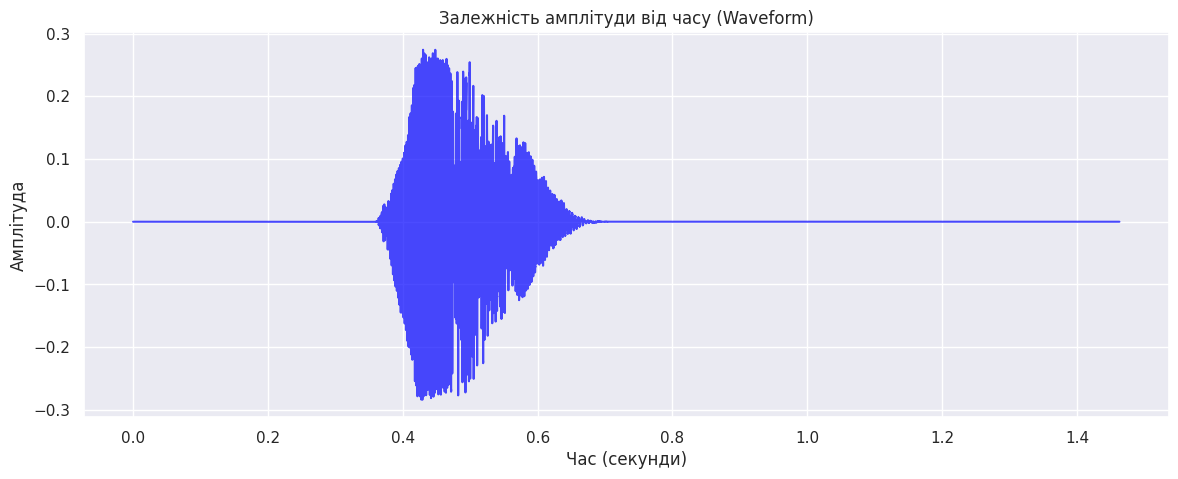

In [16]:
time = np.linspace(0, duration, num=len(samples))

plt.figure(figsize=(14, 5))
plt.plot(time, samples, color='blue', alpha=0.7)
plt.title('Залежність амплітуди від часу (Waveform)')
plt.xlabel('Час (секунди)')
plt.ylabel('Амплітуда')
plt.grid(True)
plt.show()

Графік залежності амплітуди від часу фактично показує гучність в певний момент часу. Але він не є дуже інформативним, бо ніяким чином не показує частотну характеристику звуку. Тут нам на допомогу приходить fft. Завдання - зробити fast fourier transform нашого audio файлу і вивести графік.</br>
Має бути щось типу такого:
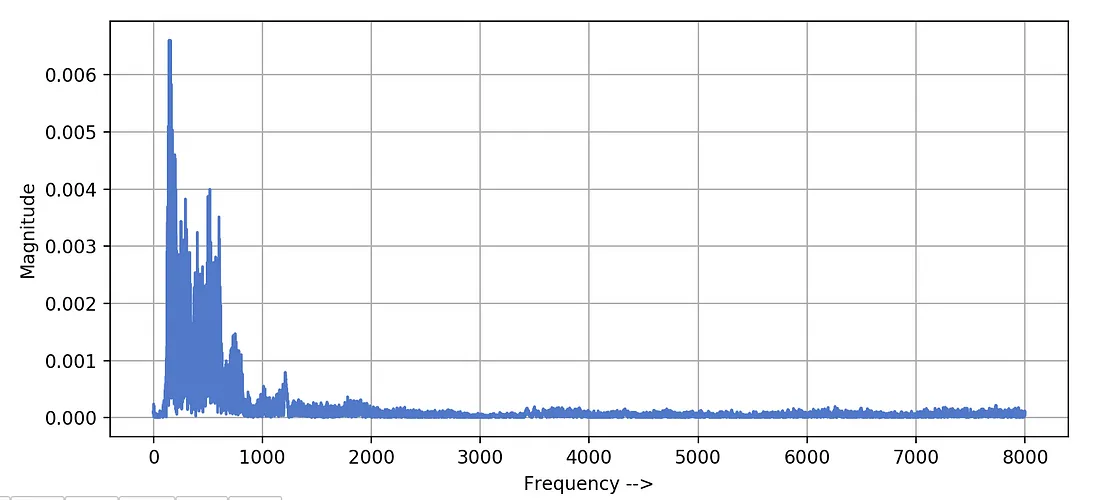

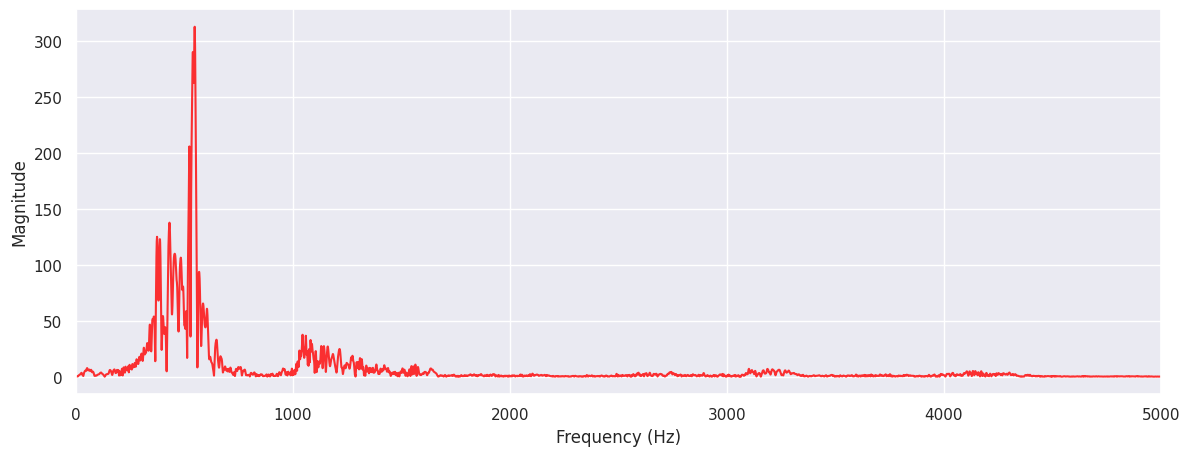

In [18]:
from scipy.fft import fft, fftfreq

N = len(samples)
yf = fft(samples)
xf = fftfreq(N, 1 / sample_rate)

half_n = N // 2
freqs = xf[:half_n]
magnitudes = np.abs(yf[:half_n])

plt.figure(figsize=(14, 5))
plt.plot(freqs, magnitudes, color='red', alpha=0.8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)

plt.xlim(0, 5000) 
plt.show()

Висновок до експериментів з аудіо: Частота та Амплітуда

1. Фільтрація за частотою (Frequency Filtering):

    Голос: З'ясував, що з голосового запису можна сміливо прибрати високі частоти (вище 4000–5000 Гц) та дуже низькі (нижче 80–100 Гц). Звук втрачає "об'ємність" і стає схожим на розмову по старому телефону, проте слова залишаються абсолютно розбірливими, а голос — впізнаваним. Основна інформація людського голосу зосереджена в середньому діапазоні (300–3000 Гц).

    Пісня: При видаленні низьких частот (басів) трек звучить "плоско", а при зрізанні високих частот втрачається чіткість ударних та дзвінкість інструментів. Однак основну мелодію та ритм легко впізнати навіть маючи лише вузьку смугу середніх частот.

2. Фільтрація за амплітудою (Amplitude Filtering / Compression):

    При відсіюванні частот з найменшими амплітудами (видалення "тихих" складових спектру) з'ясувалося, що аудіо містить величезну кількість надлишкової інформації.

    Можна "викинути" 80–90% найменших частотних компонентів Фур'є-образу, і голос чи пісня залишаться цілком впізнаваними. Урізання призводить до появи синтетичного, "металевого" або "булькотливого" відтінку (артефакти стиснення), але ритм, інтонація та слова зберігаються чудово.

Загальний підсумок: Експерименти з дискретним перетворенням Фур'є довели, що більшість даних у сирому аудіофайлі є надлишковими для людського сприйняття. Для того, щоб зберегти базову впізнаваність звуку, достатньо залишити лише вузький діапазон основних частот або невеликий відсоток частот із найбільшою амплітудою. Саме на цьому принципі втрати несуттєвої інформації базуються популярні формати стиснення аудіо, такі як MP3.

Проведіть схожий аналіз для фотографій (для цього буде корисною функція fft2). Спробуйте скомпресувати фото, поступово видаляючи з нього найменші амплітуди. Проаналізуйте, як це впливає на розмір (KiB/MiB) фото.

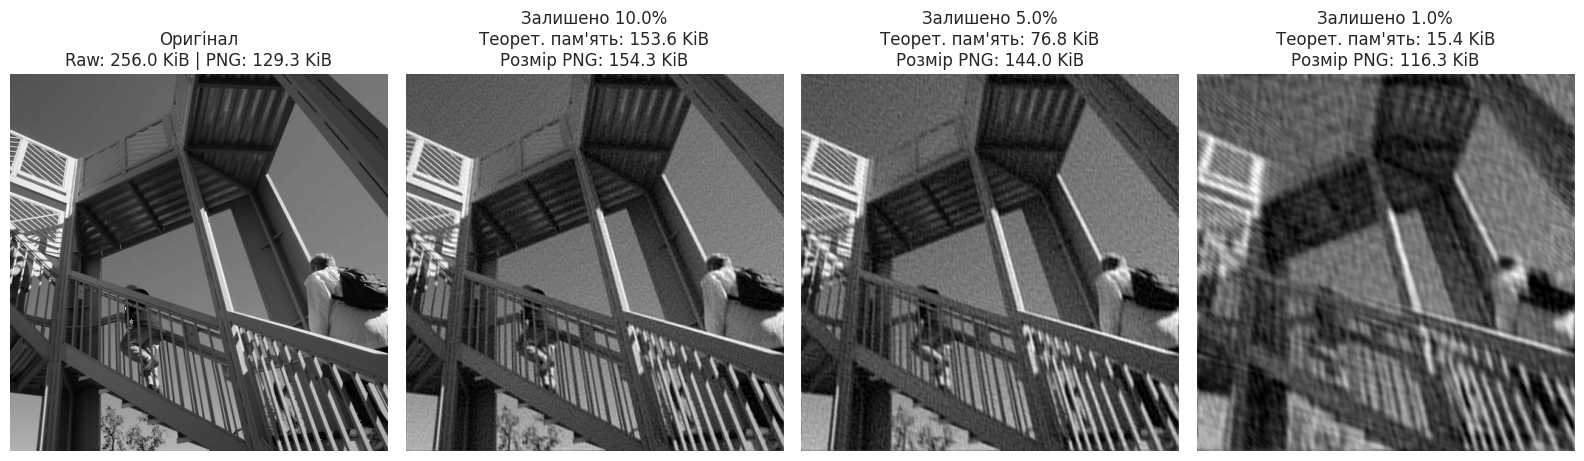

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.datasets import ascent
from PIL import Image
import os

# 1. loading standard test image (512x512 grayscale)
image = ascent()

# Saving to file
Image.fromarray(image.astype(np.uint8)).save('original.png')
orig_png_size = os.path.getsize('original.png') / 1024
# size
orig_raw_size = image.size / 1024 

# 2. Making 2D FFT and shifting zero frequency to the center
F = fft2(image)
F_shifted = fftshift(F) # Зсуваємо нульову частоту в центр для зручності

# Computing magnitudes for compression
magnitudes = np.abs(F_shifted)

def compress_image(F_shifted, magnitudes, keep_fraction):
    threshold = np.percentile(magnitudes, 100 * (1 - keep_fraction))
    
    F_compressed = F_shifted.copy()
    F_compressed[magnitudes < threshold] = 0
    
    F_ishifted = ifftshift(F_compressed)
    image_reconstructed = np.real(ifft2(F_ishifted))
    
    return F_compressed, image_reconstructed

# 3. Testing different compression levels
fractions = [0.1, 0.05, 0.01]

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title(f"Оригінал\nRaw: {orig_raw_size:.1f} KiB | PNG: {orig_png_size:.1f} KiB")
plt.axis('off')

for i, frac in enumerate(fractions):
    F_comp, img_rec = compress_image(F_shifted, magnitudes, frac)
    
    img_rec_clipped = np.clip(img_rec, 0, 255).astype(np.uint8)
    filename = f'compressed_{frac}.png'
    Image.fromarray(img_rec_clipped).save(filename)
    
    png_size = os.path.getsize(filename) / 1024
    
    non_zeros = np.count_nonzero(F_comp)
    theoretical_size = (non_zeros * 6) / 1024
    
    plt.subplot(1, 4, i+2)
    plt.imshow(img_rec_clipped, cmap='gray')
    plt.title(f"Залишено {frac*100}%\nТеорет. пам'ять: {theoretical_size:.1f} KiB\nРозмір PNG: {png_size:.1f} KiB")
    plt.axis('off')

plt.tight_layout()
plt.show()